In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df  = pd.read_csv('datasets/steamdb_top_sellers_2019-2024.csv')
df

,Tahun Rilis,Rank,Nama Game,Diskon,Harga,Rating,Tanggal Rilis,Followers,Online Saat Ini,Peak Pemain
0,2019,46.0,Destiny 2,0%,Free,79.01%,01 Oct,"719,675","23,683","316,750"
1,2019,50.0,Hunt: Showdown 1896,-50%,Rp 127500,72.01%,27 Aug,"487,821","11,991","60,124"
2,2019,78.0,STAR WARS Jedi: Fallen Order™,-75%,Rp 119750,87.54%,15 Nov,"205,752","2,262","46,550"
3,2019,81.0,Blasphemous,-90%,Rp 19999,88.56%,10 Sep,"90,902","2,274","3,465"
4,2019,121.0,Oxygen Not Included,-70%,Rp 35999,95.39%,30 Jul,"396,429","10,600","27,486"
...,...,...,...,...,...,...,...,...,...,...
595,2024,513.0,Buckshot Roulette,0%,Rp 28999,94.55%,04 Apr,"66,069",842,"20,226"
596,2024,519.0,Crusader Kings III: Roads to Power,0%,Rp 321999,80.49%,24 Sep,—,—,—
597,2024,532.0,Void Crew,0%,Rp 219000,85.42%,25 Nov,"56,198",692,"4,722"
598,2024,540.0,Abiotic Factor,0%,Rp 284999,94.38%,02 May,"99,658","1,494","21,753"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tahun Rilis      600 non-null    int64  
 1   Rank             600 non-null    float64
 2   Nama Game        600 non-null    object 
 3   Diskon           600 non-null    object 
 4   Harga            600 non-null    object 
 5   Rating           600 non-null    object 
 6   Tanggal Rilis    600 non-null    object 
 7   Followers        600 non-null    object 
 8   Online Saat Ini  600 non-null    object 
 9   Peak Pemain      600 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 47.0+ KB


In [4]:
# Mengubah kolom menjadi numerik

# Membersihkan kolom 'Harga' dari teks dan simbol mata uang
df['Harga'] = df['Harga'].astype(str).str.lower().replace({'free to play': '0', 'free': '0'}, regex=False)
df['Harga'] = df['Harga'].str.replace(r'[^\d.]', '', regex=True)
df['Harga'] = pd.to_numeric(df['Harga'], errors='coerce').fillna(0)

# Membersihkan dan mengubah kolom persentase
for col in ['Diskon', 'Rating']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Membersihkan dan mengubah kolom angka dengan koma
for col in ['Followers', 'Online Saat Ini', 'Peak Pemain']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Menampilkan tipe data setelah konversi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tahun Rilis      600 non-null    int64  
 1   Rank             600 non-null    float64
 2   Nama Game        600 non-null    object 
 3   Diskon           600 non-null    int64  
 4   Harga            600 non-null    float64
 5   Rating           600 non-null    float64
 6   Tanggal Rilis    600 non-null    object 
 7   Followers        600 non-null    float64
 8   Online Saat Ini  600 non-null    float64
 9   Peak Pemain      600 non-null    float64
dtypes: float64(6), int64(2), object(2)
memory usage: 47.0+ KB


In [5]:
df

,Tahun Rilis,Rank,Nama Game,Diskon,Harga,Rating,Tanggal Rilis,Followers,Online Saat Ini,Peak Pemain
0,2019,46.0,Destiny 2,0,0.0,79.01,01 Oct,719675.0,23683.0,316750.0
1,2019,50.0,Hunt: Showdown 1896,-50,127500.0,72.01,27 Aug,487821.0,11991.0,60124.0
2,2019,78.0,STAR WARS Jedi: Fallen Order™,-75,119750.0,87.54,15 Nov,205752.0,2262.0,46550.0
3,2019,81.0,Blasphemous,-90,19999.0,88.56,10 Sep,90902.0,2274.0,3465.0
4,2019,121.0,Oxygen Not Included,-70,35999.0,95.39,30 Jul,396429.0,10600.0,27486.0
...,...,...,...,...,...,...,...,...,...,...
595,2024,513.0,Buckshot Roulette,0,28999.0,94.55,04 Apr,66069.0,842.0,20226.0
596,2024,519.0,Crusader Kings III: Roads to Power,0,321999.0,80.49,24 Sep,0.0,0.0,0.0
597,2024,532.0,Void Crew,0,219000.0,85.42,25 Nov,56198.0,692.0,4722.0
598,2024,540.0,Abiotic Factor,0,284999.0,94.38,02 May,99658.0,1494.0,21753.0


In [6]:
# 1. Mengubah nama kolom menjadi format snake_case
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 2. Membuat kolom 'apakah_diskon'
# Jika diskon bukan 0, maka 1, selain itu 0
df['apakah_diskon'] = (df['diskon'] != 0).astype(int)

# 3. Membuat kolom 'apakah_gratis'
# Jika harga adalah 0, maka 1, selain itu 0
df['apakah_gratis'] = (df['harga'] == 0).astype(int)

# 4. Menggabungkan dan mengonversi kolom tanggal
# Menggabungkan string dari tanggal dan tahun
df['tanggal_rilis_lengkap'] = df['tanggal_rilis'].astype(str) + ' ' + df['tahun_rilis'].astype(str)
# Mengonversi ke format datetime, menangani kemungkinan error
df['tanggal_rilis_lengkap'] = pd.to_datetime(df['tanggal_rilis_lengkap'], format='%d %b %Y', errors='coerce')

# 5. Membuat kolom 'selling_rank' berdasarkan tahun dari tanggal yang baru
df['selling_rank'] = df.groupby(df['tanggal_rilis_lengkap'].dt.year).cumcount() + 1

# 6. Menghapus kolom asli yang sudah tidak diperlukan
df.drop(columns=['tanggal_rilis', 'tahun_rilis'], inplace=True)

# Menampilkan beberapa baris pertama dengan kolom baru
df

,rank,nama_game,diskon,harga,rating,followers,online_saat_ini,peak_pemain,apakah_diskon,apakah_gratis,tanggal_rilis_lengkap,selling_rank
0,46.0,Destiny 2,0,0.0,79.01,719675.0,23683.0,316750.0,0,1,2019-10-01,1
1,50.0,Hunt: Showdown 1896,-50,127500.0,72.01,487821.0,11991.0,60124.0,1,0,2019-08-27,2
2,78.0,STAR WARS Jedi: Fallen Order™,-75,119750.0,87.54,205752.0,2262.0,46550.0,1,0,2019-11-15,3
3,81.0,Blasphemous,-90,19999.0,88.56,90902.0,2274.0,3465.0,1,0,2019-09-10,4
4,121.0,Oxygen Not Included,-70,35999.0,95.39,396429.0,10600.0,27486.0,1,0,2019-07-30,5
...,...,...,...,...,...,...,...,...,...,...,...,...
595,513.0,Buckshot Roulette,0,28999.0,94.55,66069.0,842.0,20226.0,0,0,2024-04-04,96
596,519.0,Crusader Kings III: Roads to Power,0,321999.0,80.49,0.0,0.0,0.0,0,0,2024-09-24,97
597,532.0,Void Crew,0,219000.0,85.42,56198.0,692.0,4722.0,0,0,2024-11-25,98
598,540.0,Abiotic Factor,0,284999.0,94.38,99658.0,1494.0,21753.0,0,0,2024-05-02,99


In [7]:
df

,rank,nama_game,diskon,harga,rating,followers,online_saat_ini,peak_pemain,apakah_diskon,apakah_gratis,tanggal_rilis_lengkap,selling_rank
0,46.0,Destiny 2,0,0.0,79.01,719675.0,23683.0,316750.0,0,1,2019-10-01,1
1,50.0,Hunt: Showdown 1896,-50,127500.0,72.01,487821.0,11991.0,60124.0,1,0,2019-08-27,2
2,78.0,STAR WARS Jedi: Fallen Order™,-75,119750.0,87.54,205752.0,2262.0,46550.0,1,0,2019-11-15,3
3,81.0,Blasphemous,-90,19999.0,88.56,90902.0,2274.0,3465.0,1,0,2019-09-10,4
4,121.0,Oxygen Not Included,-70,35999.0,95.39,396429.0,10600.0,27486.0,1,0,2019-07-30,5
...,...,...,...,...,...,...,...,...,...,...,...,...
595,513.0,Buckshot Roulette,0,28999.0,94.55,66069.0,842.0,20226.0,0,0,2024-04-04,96
596,519.0,Crusader Kings III: Roads to Power,0,321999.0,80.49,0.0,0.0,0.0,0,0,2024-09-24,97
597,532.0,Void Crew,0,219000.0,85.42,56198.0,692.0,4722.0,0,0,2024-11-25,98
598,540.0,Abiotic Factor,0,284999.0,94.38,99658.0,1494.0,21753.0,0,0,2024-05-02,99


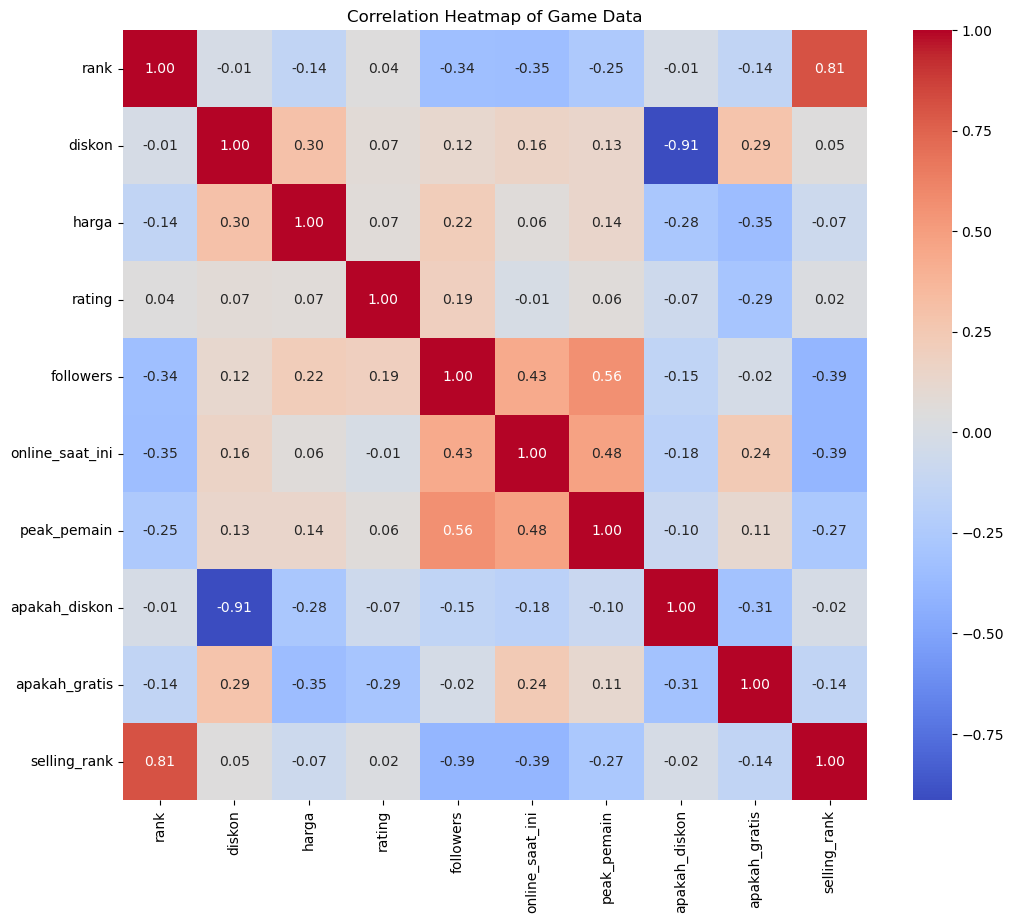

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Game Data')
plt.show()

# KNeighborsRegressor Manual (Tanpa Library ML)

Prediksi peak_pemain menggunakan KNeighborsRegressor manual (tanpa scikit-learn) dan evaluasi MSE serta R2.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Data
fitur = ['harga', 'diskon', 'rating', 'followers', 'apakah_diskon', 'apakah_gratis', 'selling_rank']
target = 'peak_pemain'
df_reg = df[fitur + [target]]
X = df_reg[fitur].values
y = df_reg[target].values

# Split data

# KNeighborsRegressor manual (k=5, Euclidean)
def knn_regressor_predict(X_train, y_train, X_test, k=4):
    preds = []
    for x in X_test:
        dists = np.linalg.norm(X_train - x, axis=1)
        idx_knn = np.argsort(dists)[:k]
        pred = np.mean(y_train[idx_knn])
        preds.append(pred)
    return np.array(preds)

# Prediksi
y_pred_knn = knn_regressor_predict(X_train, y_train, X_test, k=4)

# Evaluasi
mse_knn = np.mean((y_test - y_pred_knn) ** 2)
mae_knn = np.mean(np.abs(y_test - y_pred_knn))
r2_knn = 1 - np.sum((y_test - y_pred_knn) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

print(f"Manual KNN Regressor (k=5) MSE: {mse_knn:.2f}")
print(f"Manual KNN Regressor (k=5) MAE: {mae_knn:.2f}")
print(f"Manual KNN Regressor (k=5) R2: {r2_knn:.4f}")

# Tampilkan 10 prediksi pertama
for i in range(10):
    print(f"Fitur: {[X_test[i, j] for j in range(X_test.shape[1])]}, Actual: {y_test[i]}, Predicted: {y_pred_knn[i]:.2f}")

Manual KNN Regressor (k=5) MSE: 1188195178.96
Manual KNN Regressor (k=5) MAE: 18102.99
Manual KNN Regressor (k=5) R2: 0.9358
Fitur: [np.float64(63000.0), np.float64(-70.0), np.float64(81.56), np.float64(172996.0), np.float64(1.0), np.float64(0.0), np.float64(11.0)], Actual: 11696.0, Predicted: 40849.50
Fitur: [np.float64(0.0), np.float64(0.0), np.float64(24.59), np.float64(99261.0), np.float64(0.0), np.float64(1.0), np.float64(20.0)], Actual: 75608.0, Predicted: 27177.50
Fitur: [np.float64(65000.0), np.float64(0.0), np.float64(89.67), np.float64(124679.0), np.float64(0.0), np.float64(0.0), np.float64(66.0)], Actual: 113798.0, Predicted: 46368.25
Fitur: [np.float64(162999.0), np.float64(0.0), np.float64(83.29), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(78.0)], Actual: 0.0, Predicted: 0.00
Fitur: [np.float64(51502.0), np.float64(-55.0), np.float64(96.14), np.float64(48393.0), np.float64(1.0), np.float64(0.0), np.float64(82.0)], Actual: 772.0, Predicted: 10169.00
Fitur

KNeighborsRegressor manual ini menggunakan k=5 dan jarak Euclidean. Untuk dataset besar, gunakan library ML seperti scikit-learn agar lebih efisien.


## Interpretasi Hasil Manual KNeighborsRegressor

- **MSE (Mean Squared Error)**: Mengukur rata-rata kuadrat selisih antara nilai aktual dan prediksi. Semakin kecil nilainya, semakin baik model dalam memprediksi data.
- **MAE (Mean Absolute Error)**: Mengukur rata-rata nilai absolut selisih antara nilai aktual dan prediksi. Nilai yang lebih kecil menandakan prediksi yang lebih akurat.
- **R2 (R-squared)**: Menunjukkan seberapa baik variansi data target dijelaskan oleh model. Nilai R2 mendekati 1 berarti model sangat baik, sedangkan mendekati 0 berarti model kurang baik.

Pada contoh di atas, model KNN manual digunakan untuk memprediksi `peak_pemain`. Jika nilai MSE dan MAE cukup kecil serta R2 mendekati 1, maka model sudah cukup baik. Namun, untuk dataset besar atau kebutuhan produksi, sebaiknya gunakan library seperti scikit-learn agar lebih efisien dan akurat.
